# Лабораторная работа №3 по дисциплине "Основы нейронных сетей"

Выполнили cтуденты группы 3311:
- Шарпинский Денис
- Локтионов Тимофей
- Суздалева Алёна

Датасет: https://www.kaggle.com/datasets/andrewmvd/animal-faces

In [1]:
# =========================
# Блок 1. Импорты и базовая настройка окружения
# =========================

from pathlib import Path
import math
import random
import time

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.utils import make_grid

from tqdm.auto import tqdm


# -------------------------
# Фиксация seed для воспроизводимости
# -------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# -------------------------
# Выбор устройства
# -------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Устройство:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version в PyTorch:", torch.version.cuda)
else:
    print("CUDA недоступна. Обучение будет идти на CPU.")

PyTorch: 2.12.0+cpu
Torchvision: 0.27.0+cpu
Устройство: cpu
CUDA недоступна. Обучение будет идти на CPU.


c:\projects\year3\sem6\ai\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pathlib import Path

DATASET_DIR = Path("dataset_64")   
IMG_SIZE = 32                      
CHANNELS = 3

BATCH_SIZE = 32                    
NUM_WORKERS = 0                    

N_STEPS = 100                      
EPOCHS = 10                        
LR = 2e-4

MODEL_SAVE_PATH = "ddpm_animal_faces_32.pt"

print("DATASET_DIR =", DATASET_DIR.resolve())
print("IMG_SIZE =", IMG_SIZE)
print("BATCH_SIZE =", BATCH_SIZE)
print("N_STEPS =", N_STEPS)
print("EPOCHS =", EPOCHS)
print("LR =", LR)

DATASET_DIR = C:\projects\year3\sem6\ai_3\dataset_64
IMG_SIZE = 32
BATCH_SIZE = 32
N_STEPS = 100
EPOCHS = 10
LR = 0.0002


In [3]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


class AnimalFacesDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        
        self.image_paths = [
            p for p in self.root_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        ]
        
        self.image_paths.sort()
        
        if len(self.image_paths) == 0:
            raise ValueError(f"В папке {self.root_dir} не найдено изображений")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform is not None:
            image = self.transform(image)
            
        return image


transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),                  # [0, 1]
    transforms.Normalize([0.5]*3, [0.5]*3) # -> [-1, 1]
])

train_dataset = AnimalFacesDataset(DATASET_DIR / "train", transform=transform)
val_dataset   = AnimalFacesDataset(DATASET_DIR / "val", transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    drop_last=False
)

print("Train images:", len(train_dataset))
print("Val images:", len(val_dataset))
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train images: 14630
Val images: 1500
Train batches: 457
Val batches: 47


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.utils import make_grid


def denorm(x):
    """
    Перевод из [-1, 1] в [0, 1]
    """
    return (x.clamp(-1, 1) + 1) / 2


def show_tensor_images(images, nrow=8, figsize=(12, 6), title=None):
    """
    images: tensor [B, C, H, W]
    """
    images = denorm(images.detach().cpu())
    grid = make_grid(images, nrow=nrow)
    np_grid = grid.permute(1, 2, 0).numpy()

    plt.figure(figsize=figsize)
    if title:
        plt.title(title)
    plt.imshow(np_grid)
    plt.axis("off")
    plt.show()

Batch shape: torch.Size([32, 3, 32, 32])


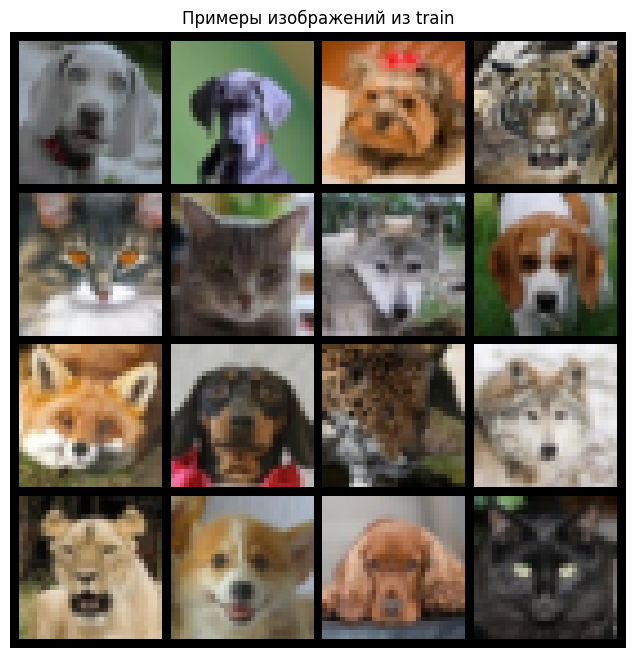

In [5]:
batch = next(iter(train_loader))
print("Batch shape:", batch.shape)  # ожидаем [B, 3, 32, 32]

show_tensor_images(batch[:16], nrow=4, figsize=(8, 8), title="Примеры изображений из train")

In [6]:
import torch

betas = torch.linspace(1e-4, 0.02, N_STEPS, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

sqrt_alpha_bars = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)


def extract(a, t, x_shape):
    """
    a: [N_STEPS]
    t: [B]
    вернуть [B, 1, 1, 1]
    """
    out = a.gather(0, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))


def q_sample(x0, t, noise=None):
    """
    x0: [B, C, H, W] - исходные изображения
    t:  [B]          - шаги
    noise: [B, C, H, W] - если None, генерируем сами
    
    Возвращает:
    xt    - зашумлённое изображение
    noise - настоящий шум
    """
    if noise is None:
        noise = torch.randn_like(x0)

    sqrt_ab = extract(sqrt_alpha_bars, t, x0.shape)
    sqrt_1mab = extract(sqrt_one_minus_alpha_bars, t, x0.shape)

    xt = sqrt_ab * x0 + sqrt_1mab * noise
    return xt, noise

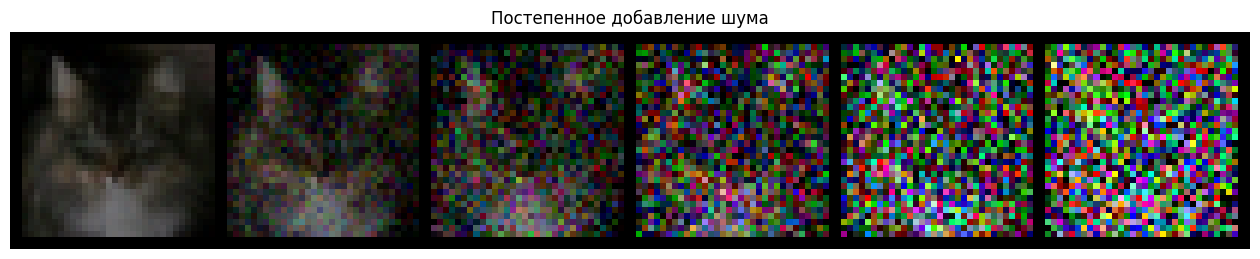

In [7]:
sample_img = train_dataset[0].unsqueeze(0).to(device)

time_steps_to_show = [0, 10, 25, 50, 75, 99]
noisy_images = []

for step in time_steps_to_show:
    t = torch.tensor([step], device=device, dtype=torch.long)
    xt, _ = q_sample(sample_img, t)
    noisy_images.append(xt.squeeze(0).cpu())

noisy_images = torch.stack(noisy_images)
show_tensor_images(noisy_images, nrow=len(time_steps_to_show), figsize=(16, 3),
                   title="Постепенное добавление шума")

In [8]:
import math
import torch.nn as nn
import torch.nn.functional as F


class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        """
        t: [B]
        return: [B, dim]
        """
        half_dim = self.dim // 2
        emb_scale = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb_scale)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
        return emb


class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, groups=8):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(groups, out_ch)
        self.act1 = nn.SiLU()

        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(groups, out_ch)
        self.act2 = nn.SiLU()

        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch)
        )

        self.residual_conv = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.act1(h)

        time_term = self.time_mlp(t_emb)[:, :, None, None]
        h = h + time_term

        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act2(h)

        return h + self.residual_conv(x)


class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, base_channels=32, time_emb_dim=128):
        super().__init__()

        self.time_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(base_channels),
            nn.Linear(base_channels, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )

        self.init_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)

        # Encoder
        self.enc1 = ResidualBlock(base_channels, base_channels, time_emb_dim)
        self.down1 = nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1)   # 32 -> 16

        self.enc2 = ResidualBlock(base_channels * 2, base_channels * 2, time_emb_dim)
        self.down2 = nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=4, stride=2, padding=1)  # 16 -> 8

        # Bottleneck
        self.mid = ResidualBlock(base_channels * 4, base_channels * 4, time_emb_dim)

        # Decoder
        self.up1 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=4, stride=2, padding=1)  # 8 -> 16
        self.dec1 = ResidualBlock(base_channels * 4, base_channels * 2, time_emb_dim)

        self.up2 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1)  # 16 -> 32
        self.dec2 = ResidualBlock(base_channels * 2, base_channels, time_emb_dim)

        self.final_conv = nn.Conv2d(base_channels, in_channels, kernel_size=1)

    def forward(self, x, t):
        t_emb = self.time_embedding(t)

        x = self.init_conv(x)

        s1 = self.enc1(x, t_emb)         # [B, 32, 32, 32]
        x = self.down1(s1)               # [B, 64, 16, 16]

        s2 = self.enc2(x, t_emb)         # [B, 64, 16, 16]
        x = self.down2(s2)               # [B, 128, 8, 8]

        x = self.mid(x, t_emb)           # [B, 128, 8, 8]

        x = self.up1(x)                  # [B, 64, 16, 16]
        x = torch.cat([x, s2], dim=1)    # [B, 128, 16, 16]
        x = self.dec1(x, t_emb)          # [B, 64, 16, 16]

        x = self.up2(x)                  # [B, 32, 32, 32]
        x = torch.cat([x, s1], dim=1)    # [B, 64, 32, 32]
        x = self.dec2(x, t_emb)          # [B, 32, 32, 32]

        return self.final_conv(x)

In [9]:
model = SimpleUNet(in_channels=CHANNELS, base_channels=32, time_emb_dim=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nКоличество обучаемых параметров: {num_params:,}")

SimpleUNet(
  (time_embedding): Sequential(
    (0): SinusoidalTimeEmbedding()
    (1): Linear(in_features=32, out_features=128, bias=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (init_conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc1): ResidualBlock(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
    (act1): SiLU()
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
    (act2): SiLU()
    (time_mlp): Sequential(
      (0): SiLU()
      (1): Linear(in_features=128, out_features=32, bias=True)
    )
    (residual_conv): Identity()
  )
  (down1): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc2): ResidualBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): Gr

In [10]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    iterator = tqdm(loader, desc="Train", leave=False) if tqdm is not None else loader

    for x0 in iterator:
        x0 = x0.to(device)

        batch_size = x0.shape[0]
        t = torch.randint(0, N_STEPS, (batch_size,), device=device).long()

        xt, noise = q_sample(x0, t)
        noise_pred = model(xt, t)

        loss = criterion(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_size

    return total_loss / len(loader.dataset)


@torch.no_grad()
def validate_one_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0

    iterator = tqdm(loader, desc="Val", leave=False) if tqdm is not None else loader

    for x0 in iterator:
        x0 = x0.to(device)

        batch_size = x0.shape[0]
        t = torch.randint(0, N_STEPS, (batch_size,), device=device).long()

        xt, noise = q_sample(x0, t)
        noise_pred = model(xt, t)

        loss = criterion(noise_pred, noise)
        total_loss += loss.item() * batch_size

    return total_loss / len(loader.dataset)

In [11]:
train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss = validate_one_epoch(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    elapsed = time.time() - start_time

    print(f"Epoch [{epoch}/{EPOCHS}] | "
          f"train_loss={train_loss:.6f} | "
          f"val_loss={val_loss:.6f} | "
          f"time={elapsed:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"  -> Лучшая модель сохранена: {MODEL_SAVE_PATH}")

Epoch [1/10] | train_loss=0.211035 | val_loss=0.135121 | time=127.6s
  -> Лучшая модель сохранена: ddpm_animal_faces_32.pt


Epoch [2/10] | train_loss=0.127355 | val_loss=0.114868 | time=45.6s
  -> Лучшая модель сохранена: ddpm_animal_faces_32.pt


Epoch [3/10] | train_loss=0.120603 | val_loss=0.117905 | time=45.1s


Epoch [4/10] | train_loss=0.114394 | val_loss=0.109247 | time=45.5s
  -> Лучшая модель сохранена: ddpm_animal_faces_32.pt


Epoch [5/10] | train_loss=0.110888 | val_loss=0.111618 | time=45.5s


Epoch [6/10] | train_loss=0.108106 | val_loss=0.101710 | time=45.6s
  -> Лучшая модель сохранена: ddpm_animal_faces_32.pt


Epoch [7/10] | train_loss=0.107766 | val_loss=0.108330 | time=46.2s


Epoch [8/10] | train_loss=0.106485 | val_loss=0.104525 | time=46.2s


Epoch [9/10] | train_loss=0.104586 | val_loss=0.103206 | time=45.5s


Epoch [10/10] | train_loss=0.103510 | val_loss=0.100211 | time=45.6s
  -> Лучшая модель сохранена: ddpm_animal_faces_32.pt


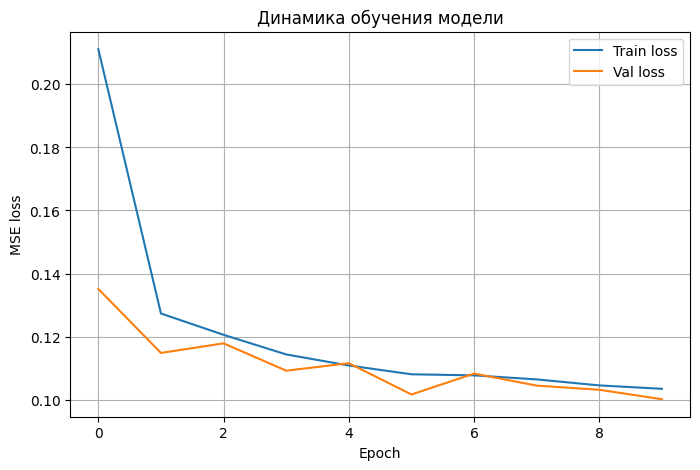

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Динамика обучения модели")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
best_model = SimpleUNet(in_channels=CHANNELS, base_channels=32, time_emb_dim=128).to(device)
best_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
best_model.eval()

print("Лучшая модель загружена.")

Лучшая модель загружена.


In [14]:
@torch.no_grad()
def p_sample(model, xt, t):
    """
    Один шаг обратной диффузии.
    xt: [B, C, H, W]
    t:  [B]
    """
    beta_t = extract(betas, t, xt.shape)
    alpha_t = extract(alphas, t, xt.shape)
    alpha_bar_t = extract(alpha_bars, t, xt.shape)
    sqrt_one_minus_alpha_bar_t = extract(sqrt_one_minus_alpha_bars, t, xt.shape)

    eps_theta = model(xt, t)

    # Среднее обратного распределения
    mean = (1 / torch.sqrt(alpha_t)) * (
        xt - (beta_t / sqrt_one_minus_alpha_bar_t) * eps_theta
    )

    # На последнем шаге шум уже не добавляем
    noise = torch.randn_like(xt)
    nonzero_mask = (t != 0).float().reshape(xt.shape[0], 1, 1, 1)

    sample = mean + nonzero_mask * torch.sqrt(beta_t) * noise
    return sample


@torch.no_grad()
def sample_images(model, n_samples=8, img_size=32, channels=3, save_intermediate=False):
    model.eval()

    xt = torch.randn(n_samples, channels, img_size, img_size, device=device)

    trajectory = []
    if save_intermediate:
        trajectory.append(xt.detach().cpu())

    for step in reversed(range(N_STEPS)):
        t = torch.full((n_samples,), step, device=device, dtype=torch.long)
        xt = p_sample(model, xt, t)

        if save_intermediate and step in [99, 75, 50, 25, 10, 0]:
            trajectory.append(xt.detach().cpu())

    return xt.detach().cpu(), trajectory

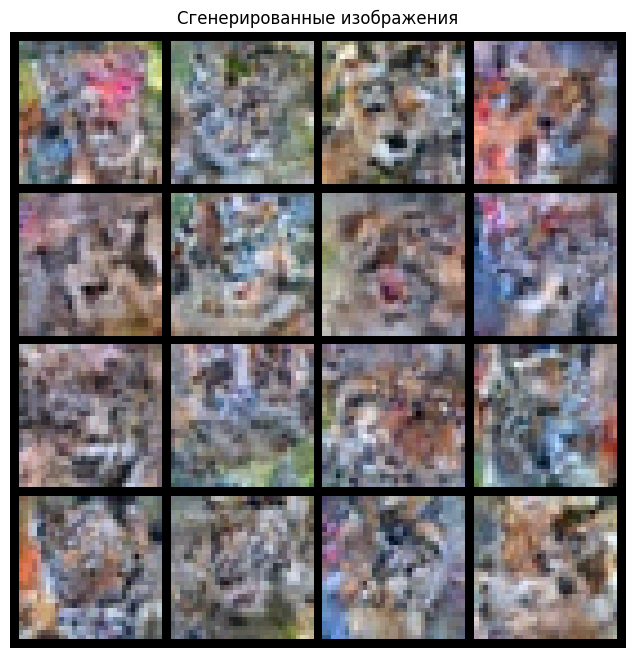

In [15]:
generated_images, trajectory = sample_images(
    best_model,
    n_samples=16,
    img_size=IMG_SIZE,
    channels=CHANNELS,
    save_intermediate=True
)

show_tensor_images(generated_images, nrow=4, figsize=(8, 8), title="Сгенерированные изображения")

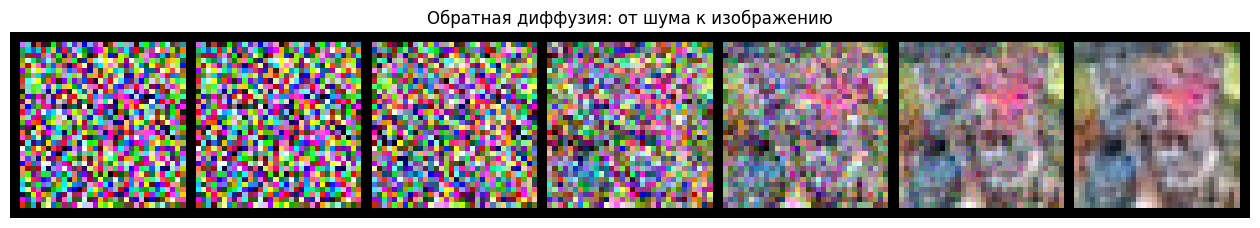

In [16]:
trajectory_single = torch.stack([step[0] for step in trajectory], dim=0)

show_tensor_images(
    trajectory_single,
    nrow=len(trajectory_single),
    figsize=(16, 3),
    title="Обратная диффузия: от шума к изображению"
)